# Credit Card Fraud Detection - PCA Encrypted Dataset

**Dataset Overview & Anomaly Detection:**
This dataset contains credit card transactions, and the primary goal is anomaly detection (identifying fraudulent transactions among legitimate ones).
Due to confidentiality and privacy concerns, the dataset is a **PCA (Principal Component Analysis) encrypted dataset**. 
- The original features are not provided.
- Features `V1`, `V2`, ... `V28` are the principal components obtained through the PCA transformation.
- The only features that have not been transformed are `Time` (seconds elapsed between each transaction and the first transaction) and `Amount` (transaction amount).
- The `Class` feature is the target variable, where `1` represents a fraudulent transaction and `0` represents a legitimate transaction.

This severe class imbalance requires specialized handling and evaluation metrics.

### Importing Required Libraries
We import libraries for data analysis (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and machine learning preprocessing and modeling (`sklearn`).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

### Loading the Dataset
We load the transaction data from `creditcard.csv` into a pandas DataFrame.

In [3]:
# load the data set

df = pd.read_csv("creditcard.csv")

### Inspecting the Data
We use `.head()` to preview the first five rows of the dataset.

In [4]:
# print the basic info

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Dataset Dimensions
We check the `.shape` of the DataFrame to see the number of rows and columns.

In [5]:
# shape of the data set

df.shape

(284807, 31)

### Dataset Information
We use `.info()` to get a summary of the dataset's column data types and non-null values.

In [6]:
# info of the data set

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

### Statistical Summary
We use `.describe()` to view the basic statistical details like mean, standard deviation, and percentiles for the numerical features.

In [7]:
# description of the data set

df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Missing Value Checker
We verify if there are any missing values in the dataset using `.isnull().sum()`.

In [8]:
# null value checker

df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### Class Distribution Math
We calculate the absolute counts and the percentage of legitimate vs. fraudulent transactions to quantify the class imbalance.

In [9]:
# Class distribution math
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print("\n--- Class distribution ---")
print(class_counts)
print("\n--- Class distribution (%) ---")
print(class_pct.round(4))


--- Class distribution ---
Class
0    284315
1       492
Name: count, dtype: int64

--- Class distribution (%) ---
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


### The Visual Proof (Seaborn)
We visualize the class distribution using a count plot. A logarithmic scale is applied to the y-axis so that the very small number of fraudulent transactions is visible.

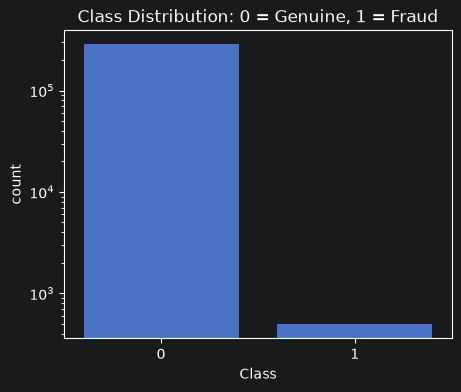

In [10]:
# The Visual Proof (Seaborn)
plt.figure(figsize=(5, 4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution: 0 = Genuine, 1 = Fraud")
plt.yscale('log')  # Log scale makes the tiny 0.17% fraud bar visible
plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

### Feature Correlation Analysis: Full Heatmap

To begin the feature selection process, we first need to understand how the features relate to one another and to our target variable (`Class`). 
We calculate the Pearson correlation coefficient matrix for the entire dataset. A heatmap is then generated to visualize these correlations. 
- **High positive or negative correlations between independent features** (multicollinearity) might indicate redundant information. 
- **Correlations with the target variable** help us identify which features might be the most predictive. 
*Note: We save this visualization as `full_correlation_heatmap.png` for reporting.*

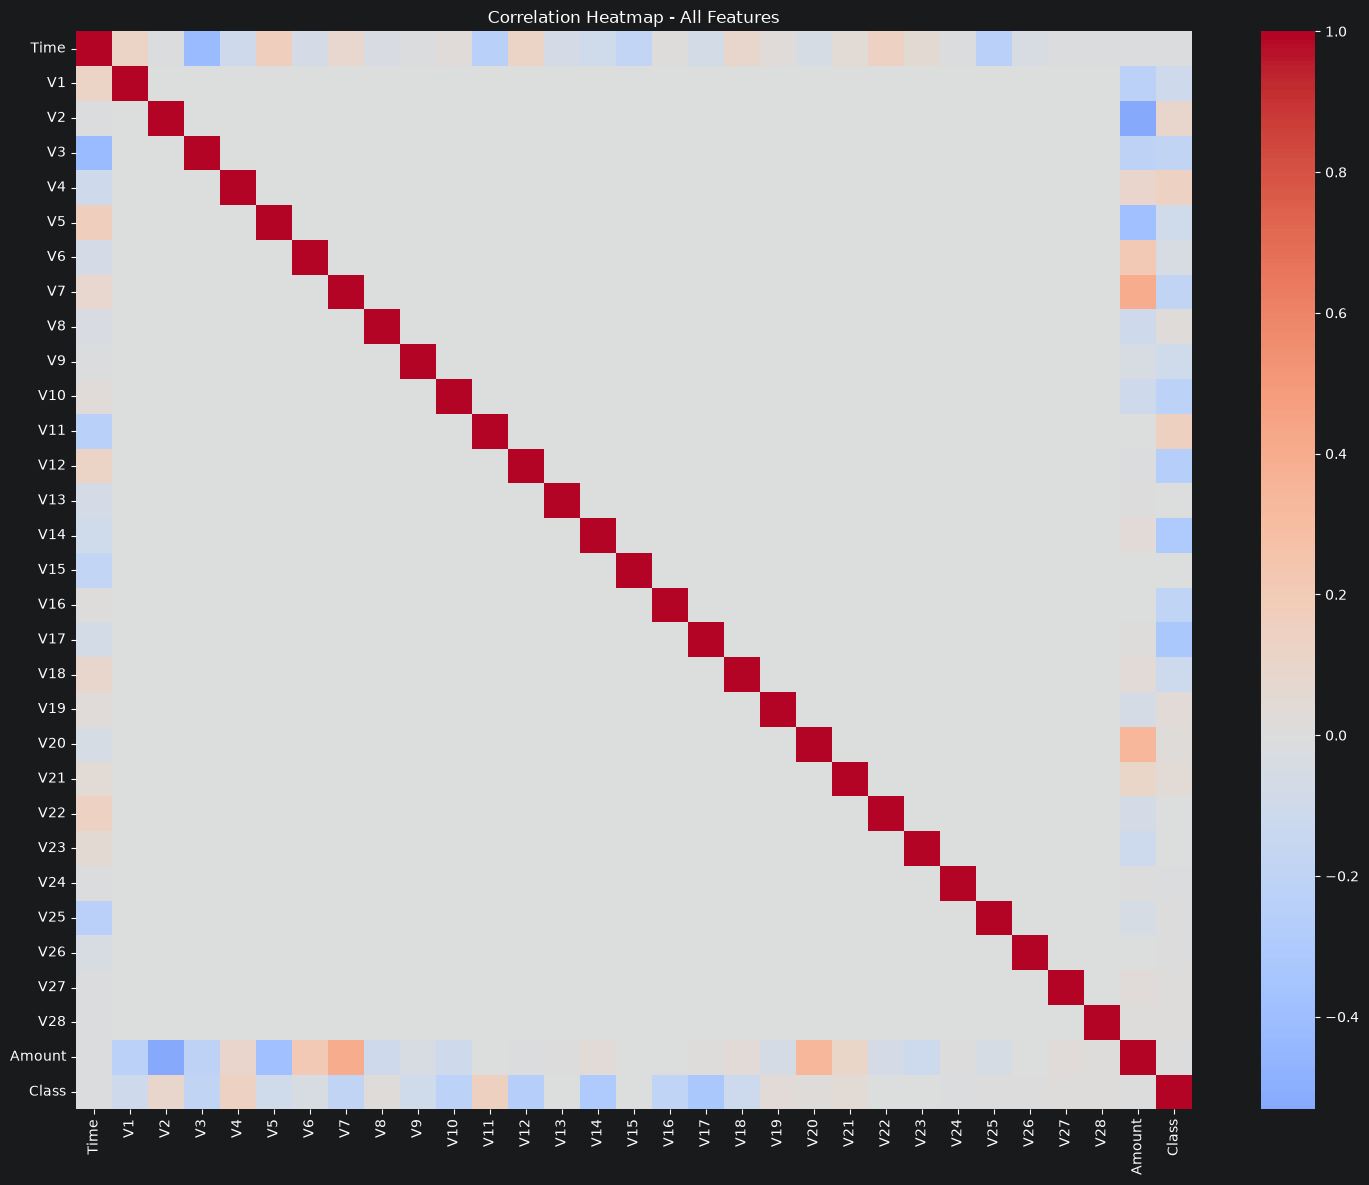

In [11]:
plt.figure(figsize=(18, 14))
corr_matrix = df.corr()

# Seaborn paints the heatmap
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title("Correlation Heatmap - All Features")
plt.savefig("graphs/full_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

### Selecting Features via Pearson Correlation to Target

While the full heatmap gives a macroscopic view, we are most interested in how each feature correlates specifically with the `Class` (fraud or genuine). 
In this step, we:
1. Extract the correlation values of all features against the `Class` column.
2. Sort them by their **absolute magnitude** to identify the strongest linear relationships, whether positive or negative.
3. Visualize these linear relationships using a horizontal bar chart (green for positive correlation, red for negative).
4. Extract the **top 10 most correlated features**. This provides us with our first candidate subset of predictive features.

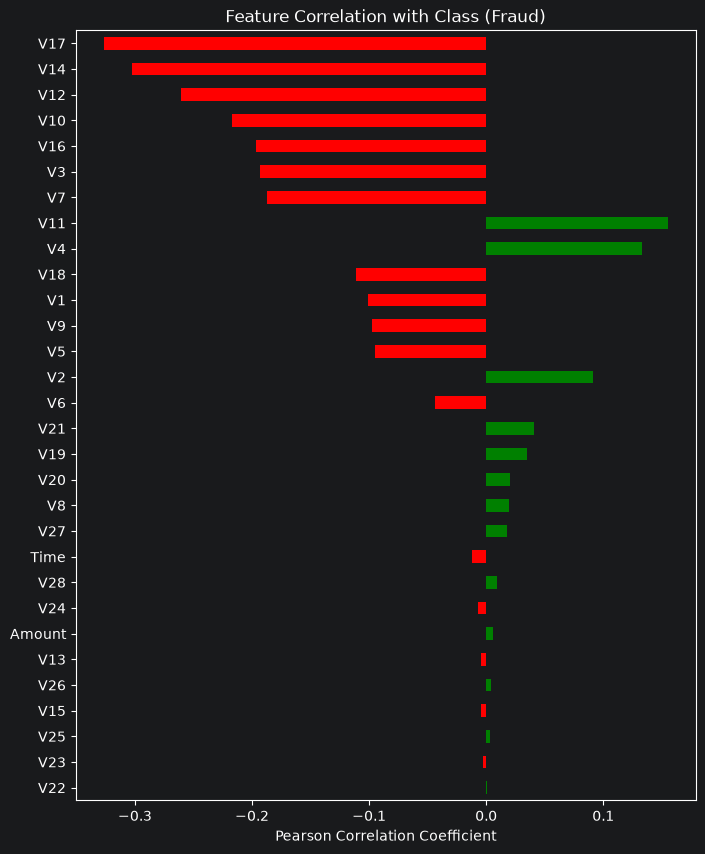


--- Top 10 features selected by Pearson correlation ---
['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18']


In [12]:
# Grab absolute correlations to the target, sort highest to lowest
target_corr = corr_matrix['Class'].drop('Class').sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 10))
target_corr.plot(kind='barh', color=['red' if v < 0 else 'green' for v in target_corr])
plt.title("Feature Correlation with Class (Fraud)")
plt.xlabel("Pearson Correlation Coefficient")
plt.gca().invert_yaxis()
plt.savefig("graphs/feature_target_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

# Save the top 10 features into a list
N = 10
top_features = target_corr.abs().sort_values(ascending=False).head(N).index.tolist()
print(f"\n--- Top {N} features selected by Pearson correlation ---")
print(top_features)

### Tree-Based Feature Selection: Random Forest Importance

Linear correlation (Pearson) only captures linear relationships. To capture complex, non-linear relationships and interactions between features, we utilize a tree-based model.
Here, we:
1. Separate our features (`X`) and target (`y`).
2. **Scale the Data:** We apply `StandardScaler` to the `Amount` and `Time` columns. While Random Forests are scale-invariant, scaling is a best practice if we plan to use these features in distance-based models later. *(Note: The PCA features V1-V28 are already scaled).* 
3. **Train a Random Forest:** We train a `RandomForestClassifier`. Crucially, we set `class_weight='balanced'` to penalize mistakes on the minority fraud class, preventing the model from just predicting 'genuine' every time.
4. **Extract Importances:** We extract the `feature_importances_` attribute, which measures how much each feature contributes to reducing impurity across all trees in the forest.
5. We visualize and extract the **top 10 features** identified by the Random Forest.

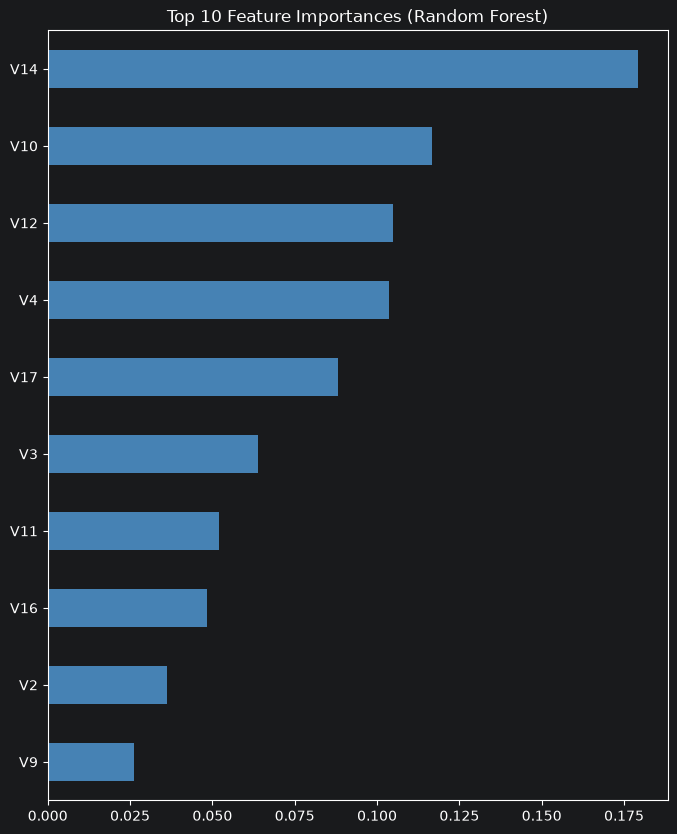

In [13]:
X = df.drop(columns=['Class'])
y = df['Class']

# Scale Amount and Time
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])

# Train the Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1 # This tells your i7 processor to use all its cores!
)
rf.fit(X_scaled, y)

# Extract and plot the best features
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
importances.head(N).plot(kind='barh', color='steelblue')
plt.title(f"Top {N} Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.savefig("graphs/rf_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

### Final Feature Set: The Magic Merge (Union)

We now have two distinct perspectives on feature importance:
1. **Pearson Correlation:** Identifies strong linear relationships.
2. **Random Forest:** Identifies non-linear patterns and complex feature interactions.

To build the most robust predictive model, we combine the insights from both methods. By performing a mathematical **Union** of the two sets of top 10 features, we ensure that we do not miss out on features that might be deemed important by one method but overlooked by the other. This final merged set will be used for training our subsequent anomaly detection classification models.

In [14]:
# Grab the top 10 from Random Forest
rf_top = importances.head(N).index.tolist()

# The Magic Merge (Union)
final_features = sorted(set(top_features) | set(rf_top))

print(f"\n--- FINAL SELECTED FEATURES ({len(final_features)}) ---")
print(final_features)


--- FINAL SELECTED FEATURES (12) ---
['V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V2', 'V3', 'V4', 'V7', 'V9']
